<a href="https://colab.research.google.com/github/vadapallimaneesha/machine_learning-/blob/main/Week4Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell installs the pyspark for the environment setup.

In [ ]:
!pip install pyspark

It initiallizes the the sparksession

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

It connects to the google drive and they need the access for it.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


It read rthe csv file pf titanioc_synthetic-data file into pyspark.

In [ ]:
dataset=spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True,header=True)

In [ ]:
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [ ]:
dataset.describe().select("Pclass","SibSp","Parch","Fare","Age","Sex","Survived","Embarked_Q","Embarked_S").show()

+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|            Pclass|             SibSp|             Parch|              Fare|               Age|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|            1000000|           1000000|
|          1.999411|          4.500906|          4.497493| 254.9829083944402|         39.517847|           0.50082|           0.49987|           0.332717|          0.333661|
|0.8168263709530482|2.8714427426552285|2.8728101169393594|141.53963219142216|23.092708389398037|0.4999995775993916|0.5000002331001

In [ ]:
from pyspark.sql.functions import col,isnan,when,count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



This cell replaces the specific 0 values in certain numericala columns.

In [ ]:
import numpy as np
from pyspark.sql.functions import when
dataset=dataset.withColumn("Pclass",when(dataset.Pclass==0,np.nan).otherwise (dataset.Pclass))
dataset=dataset.withColumn("Age",when(dataset.Age==0,np.nan).otherwise(dataset.Age))
dataset=dataset.withColumn("SibSp",when(dataset.SibSp==0,np.nan).otherwise(dataset.SibSp))
dataset=dataset.withColumn("Parch",when(dataset.Parch==0,np.nan).otherwise(dataset.Parch))
dataset=dataset.withColumn("Fare",when(dataset.Fare==0,np.nan).otherwise(dataset.Fare))
dataset.select("Pclass","Age","SibSp","Parch","Fare").show(5)

+------+----+-----+-----+------------------+
|Pclass| Age|SibSp|Parch|              Fare|
+------+----+-----+-----+------------------+
|   3.0|42.0|  6.0|  7.0|397.00178367782024|
|   1.0|52.0|  6.0|  7.0|302.12770032784186|
|   3.0|25.0|  3.0|  8.0| 427.1058765283985|
|   3.0|32.0|  9.0|  7.0| 326.8049924602327|
|   1.0|40.0|  NaN|  5.0|17.718838497771657|
+------+----+-----+-----+------------------+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import col,isnan,when,count
dataset.select([count(when(isnan(c),c)).alias(c) for c in dataset.columns]).show()

+------+-----+-----+------+----+---+--------+----------+----------+
|Pclass|  Age|SibSp| Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+-----+-----+------+----+---+--------+----------+----------+
|     0|12475|99708|100052|   0|  0|       0|         0|         0|
+------+-----+-----+------+----+---+--------+----------+----------+



This cell uses the pyspark imputer to handle the missing values that are introduced ansd identified.

In [ ]:
from pyspark.ml.feature import Imputer
imputer=Imputer(inputCols=["Pclass","Age","SibSp","Parch","Fare"],outputCols=["Pclass","Age","SibSp","Parch","Fare"])
model=imputer.fit(dataset)
dataset=model.transform(dataset)
dataset.show(5)

+------+----+----------------+-----+------------------+---+--------+----------+----------+
|Pclass| Age|           SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+----+----------------+-----+------------------+---+--------+----------+----------+
|   3.0|42.0|             6.0|  7.0|397.00178367782024|  0|       0|         0|         1|
|   1.0|52.0|             6.0|  7.0|302.12770032784186|  0|       0|         1|         0|
|   3.0|25.0|             3.0|  8.0| 427.1058765283985|  1|       1|         1|         0|
|   3.0|32.0|             9.0|  7.0| 326.8049924602327|  1|       0|         0|         0|
|   1.0|40.0|4.99938464409325|  5.0|17.718838497771657|  0|       0|         0|         0|
+------+----+----------------+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


the vectorassembler is used to combine the input columns into a singke vector columns names as features.

In [ ]:
if "features" in dataset.columns:
    dataset = dataset.drop("features")

# Get a fresh list of current columns, excluding the target and unwanted feature
current_cols = list(dataset.columns)
input_feature_cols = [c for c in current_cols if c not in ["Survived", "Sex"]]

# Let us import the vector assembler
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=input_feature_cols, outputCol="features")
# Now let us use the transform method to transform our dataset
dataset = assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+-----------------------------------------------------------+
|features                                                   |
+-----------------------------------------------------------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,1.0]              |
|[1.0,52.0,6.0,7.0,302.12770032784186,1.0,0.0]              |
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,0.0]               |
|[3.0,32.0,9.0,7.0,326.8049924602327,0.0,0.0]               |
|[1.0,40.0,4.99938464409325,5.0,17.718838497771657,0.0,0.0] |
|[1.0,20.0,7.0,2.0,402.54904361394784,0.0,0.0]              |
|[3.0,76.0,4.0,9.0,52.61038014285054,1.0,0.0]               |
|[2.0,22.0,4.0,7.0,196.48213366632623,0.0,0.0]              |
|[3.0,78.0,4.0,8.0,388.6259182464271,0.0,0.0]               |
|[3.0,15.0,1.0,8.0,299.45900279822325,1.0,0.0]              |
|[3.0,68.0,8.0,7.0,479.98134512112455,0.0,1.0]              |
|[3.0,3.0,7.0,1.0,93.03405698775256,1.0,0.0]                |
|[1.0,63.0,4.0,4.9975031890731465,84.64050143857706,0.0,0.0]|
|[3.0,40

This cell applies the standardscaler to normalize the features vector and it is having the preprocessing step for machine learning.

In [ ]:
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(5)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|[1.0,40.0,4.99938...|[1.22425038608049...|
+--------------------+--------------------+
only showing top 5 rows


splitting dataset into training and test by using randomsplit.

In [ ]:
train,test=dataset.randomSplit([0.8,0.2],seed=12345)

this cell calclutaes the class disstribution of survived terget variable in the training set and understands the class imbnalance.

In [ ]:
dataset_size=float(train.select("Survived").count())
numPositives=train.select("Survived").where('Survived == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

The number of ones are 400175
Percentage of ones are 50.0066229799911


this cell calculates the balancingratio used to aaddress the class imabalance.

In [ ]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.499933770200089


In [ ]:
from pyspark.sql.functions import when
train=train.withColumn("classWeights", when(train.Survived == 1,BalancingRatio).otherwise(1-BalancingRatio))
train.select("classWeights").show(5)

+-----------------+
|     classWeights|
+-----------------+
|0.499933770200089|
|0.500066229799911|
|0.499933770200089|
|0.499933770200089|
|0.499933770200089|
+-----------------+
only showing top 5 rows


this cell performs feature selection using chisqselector and it assembles the categorical features into new column categorical_featuyres_vector.

In [ ]:
from pyspark.ml.feature import ChiSqSelector, VectorAssembler

# Identify categorical features suitable for ChiSqSelector
categorical_features_for_chisq = ['Pclass', 'SibSp', 'Parch', 'Embarked_Q', 'Embarked_S']

# Assemble only these categorical features into a new vector column
categorical_assembler = VectorAssembler(inputCols=categorical_features_for_chisq, outputCol="categorical_features_vector")

train = categorical_assembler.transform(train)
test = categorical_assembler.transform(test)

# Apply ChiSqSelector to this new categorical vector
css = ChiSqSelector(featuresCol='categorical_features_vector', outputCol='Aspect', labelCol='Survived', fpr=0.05)

# Fit and transform
css_model = css.fit(train)
train = css_model.transform(train)
test = css_model.transform(test)

test.select("Aspect").show(5,truncate=False)

+---------------------+
|Aspect               |
+---------------------+
|[1.0,1.0,1.0,0.0,0.0]|
|[1.0,1.0,1.0,1.0,0.0]|
|[1.0,1.0,1.0,0.0,1.0]|
|[1.0,1.0,2.0,0.0,0.0]|
|[1.0,1.0,2.0,0.0,1.0]|
+---------------------+
only showing top 5 rows


this cell initiallizes and trains the logistic regression model.

In [ ]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Aspect",weightCol="classWeights",maxIter=10)
model=lr.fit(train)
predict_train=model.transform(train)
predict_test=model.transform(test)
predict_test.select("Survived","prediction").show(10)

+--------+----------+
|Survived|prediction|
+--------+----------+
|       1|       0.0|
|       1|       1.0|
|       0|       0.0|
|       1|       0.0|
|       1|       0.0|
|       1|       1.0|
|       0|       1.0|
|       1|       1.0|
|       0|       0.0|
|       1|       1.0|
+--------+----------+
only showing top 10 rows


this cell evaluates and it performs the trained logistic regression model binaryclassificationeveluator.

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator=BinaryClassificationEvaluator(rawPredictionCol='prediction',labelCol="Survived")
# We have only two choices: area under ROC and PR curves :-(
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})

print("Area under ROC Curve: {:.4f}".format(auroc))

predict_test.select("Survived","prediction","probability").show(15)

Area under ROC Curve: 0.4978
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       1|       0.0|[0.50014675639413...|
|       1|       1.0|[0.49922246319306...|
|       0|       0.0|[0.50068028273374...|
|       1|       0.0|[0.50004903507182...|
|       1|       0.0|[0.50058256156353...|
|       1|       1.0|[0.49912474213396...|
|       0|       1.0|[0.49995131374576...|
|       1|       1.0|[0.49995131374576...|
|       0|       0.0|[0.50038711909705...|
|       1|       1.0|[0.49985359242342...|
|       0|       1.0|[0.49975611510389...|
|       1|       0.0|[0.50028964180731...|
|       0|       0.0|[0.50028964180731...|
|       1|       1.0|[0.49883182337803...|
|       1|       1.0|[0.49975611510389...|
+--------+----------+--------------------+
only showing top 15 rows


It eveluates the logistic regression model  and it plots ther confusion matrix of recall,precision.

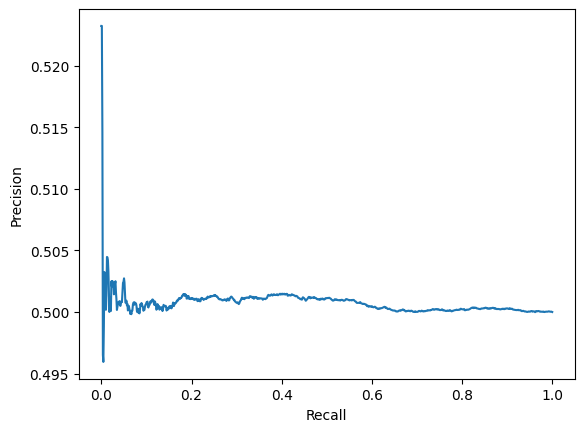

Model Accuracy 0.5010058252737514
FP rate [0.5075379521459699, 0.49045039730650736]
TR rate [0.5095496026934927, 0.49246204785403014]


In [ ]:
print(model.summary)
import matplotlib.pyplot as plt
pr = model.summary.pr.toPandas()
plt.plot(pr['recall'],pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()
print("Model Accuracy",model.summary.accuracy)
print("FP rate",model.summary.falsePositiveRateByLabel)
print("TR rate",model.summary.truePositiveRateByLabel)